In [ ]:
from pathlib import Path

from astropy import table
import matplotlib.pyplot as plt
import numpy as np

from ugdatalab import (
    GaiaData,
    Compose,
    AttachReddening, StrictReddeningCut,
    StrictBPRPCut, LindegrenC2Cut,
)
from ugdatalab.methods.bayesian.likelihoods import LinearGaussianLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample

from plotters import (
    plot_empirical_vs_catalog_extinction,
    plot_period_color_comparison,
)

In [2]:
def build_pc_arrays(data):
    """Return (x_centered, bp_rp, sigma_color, sigma_logp) for a period-color fit."""
    period = np.array(data["rrlyrae_representative_period"])
    period_err = np.array(data["rrlyrae_representative_period_error"])
    log_p = np.log10(period)
    bp_rp = np.array(data["bp_rp"])
    snr_bp = np.array(data["phot_bp_mean_flux_over_error"])
    snr_rp = np.array(data["phot_rp_mean_flux_over_error"])
    sigma_color = (2.5 / np.log(10)) * np.sqrt(1 / snr_bp**2 + 1 / snr_rp**2)
    sigma_logp = period_err / (period * np.log(10))
    return log_p - np.mean(log_p), bp_rp, sigma_color, sigma_logp

In [3]:
data = np.load(Path("artifacts/rrlyrae_calibration_sample.npz"), allow_pickle=True)
rrlyrae = table.Table({k: data[k] for k in data.files})

rrab_cal = rrlyrae[rrlyrae["best_classification"] == "RRab"]
rrc_cal = rrlyrae[rrlyrae["best_classification"] == "RRc"]

rrab_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrab_cal)))
rrc_pc_result = nuts_sample(LinearGaussianLikelihood(*build_pc_arrays(rrc_cal)))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 29 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, log10_sig]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 21 seconds.


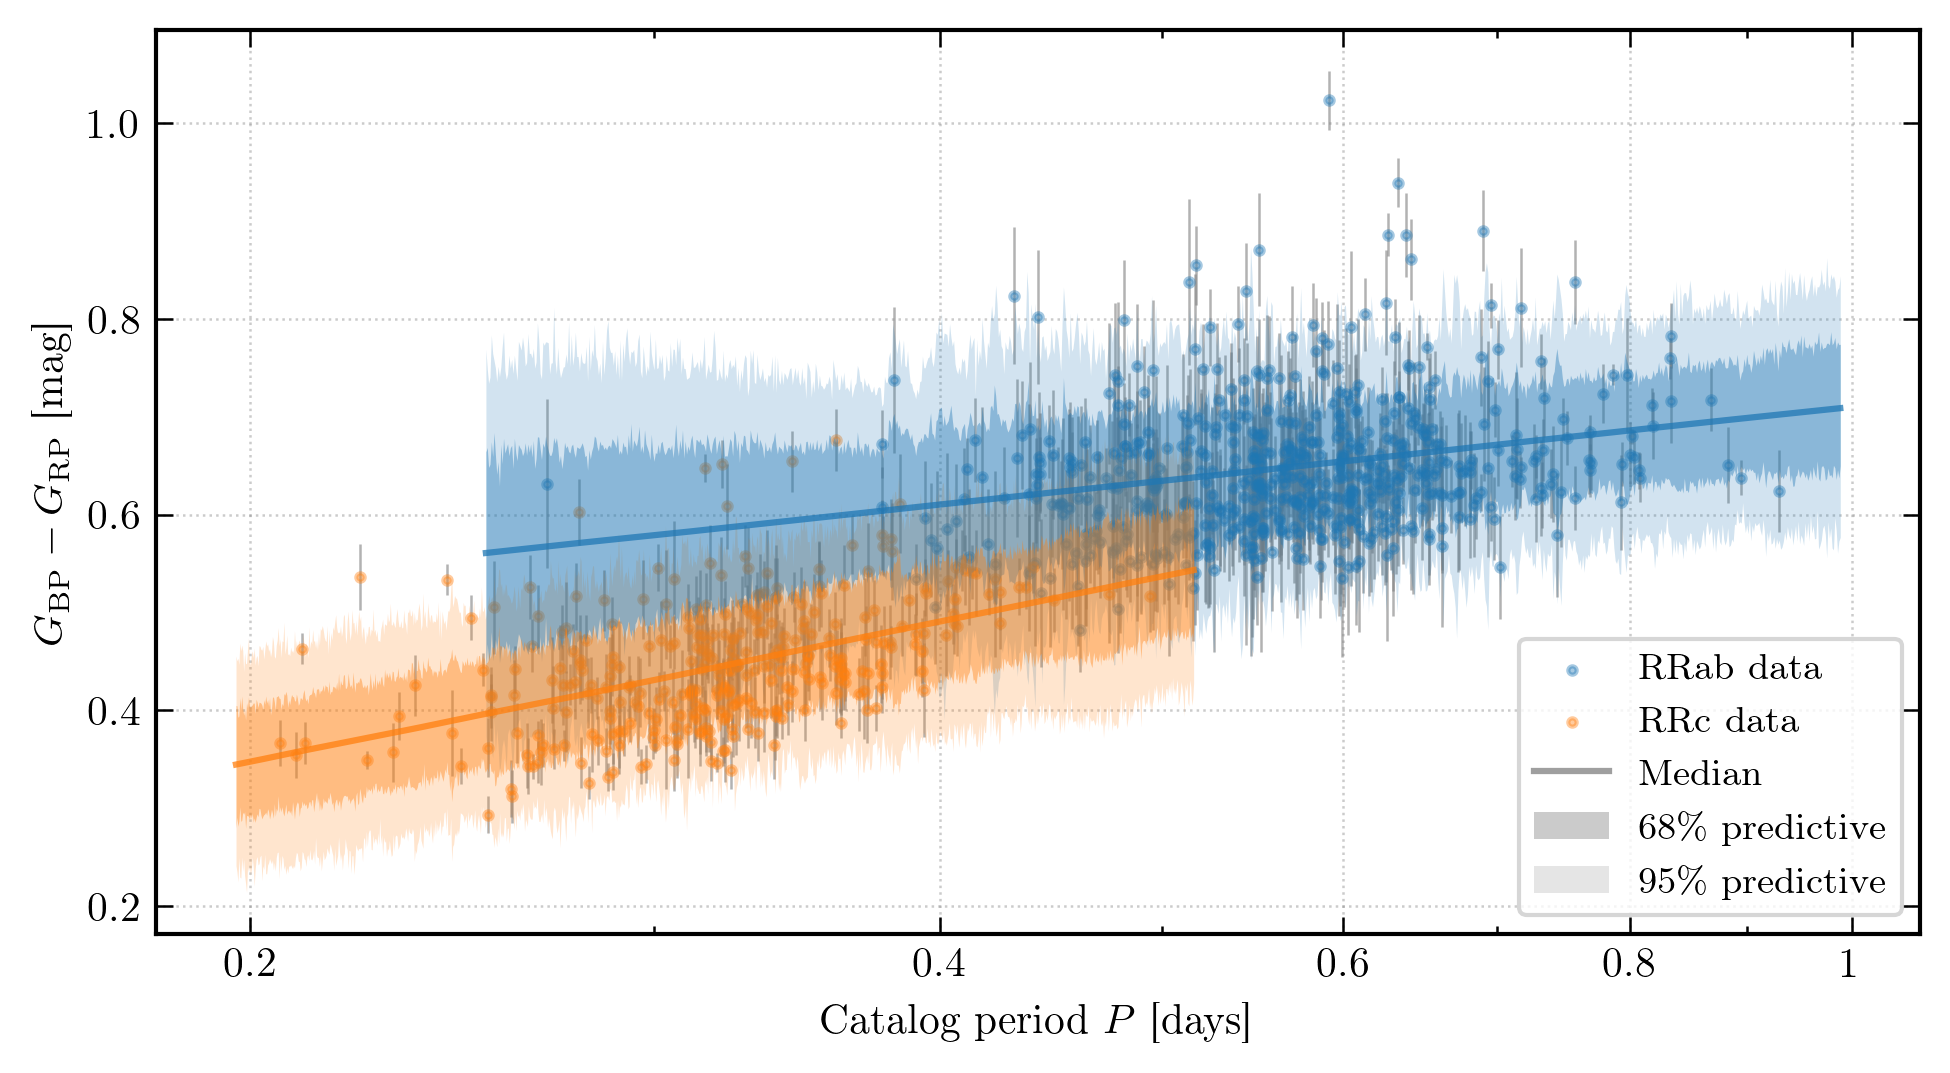

In [4]:
rrab_mean_log_p = float(np.mean(np.log10(rrab_cal["rrlyrae_representative_period"])))
rrc_mean_log_p = float(np.mean(np.log10(rrc_cal["rrlyrae_representative_period"])))

ax = plot_period_color_comparison(
    rrab_pc_result, rrc_pc_result,
    rrab_mean_log_p, rrc_mean_log_p,
)
plt.show()

In [ ]:
query = """
SELECT *
FROM gaiadr3.vari_rrlyrae AS vr
JOIN gaiadr3.gaia_source AS gs
    ON vr.source_id = gs.source_id
"""

attach_reddening = AttachReddening(
    rrab_pc=rrab_pc_result,
    rrc_pc=rrc_pc_result,
    rrab_mean_log_p=rrab_mean_log_p,
    rrc_mean_log_p=rrc_mean_log_p,
)

population_path = Path("artifacts/rrlyrae_reddening_population.npz")

if population_path.exists():
    data = np.load(population_path, allow_pickle=True)
    population = table.Table({k: data[k] for k in data.files})
else:
    population = GaiaData(query, pipeline=Compose([attach_reddening])).data
    np.savez_compressed(
        population_path,
        **{col: np.array(population[col]) for col in population.colnames},
    )

sample_path = Path("artifacts/rrlyrae_reddening_sample.npz")

if not sample_path.exists():
    sample = GaiaData(query, pipeline=Compose([
        StrictBPRPCut(),
        LindegrenC2Cut(),
        attach_reddening,
        StrictReddeningCut(),
    ])).data
    np.savez_compressed(
        sample_path,
        **{col: np.array(sample[col]) for col in sample.colnames},
    )

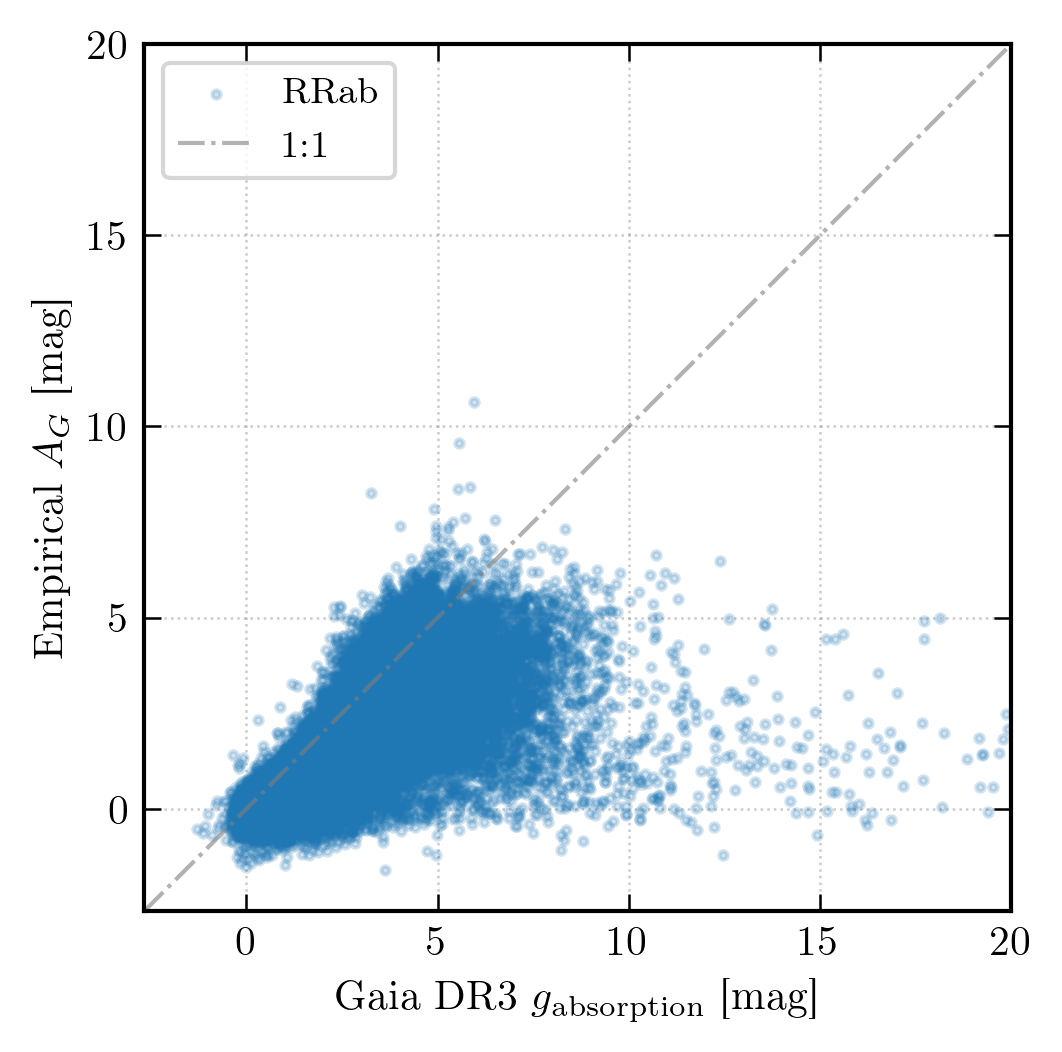

In [6]:
ax = plot_empirical_vs_catalog_extinction(population)
plt.show()